In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging

logging.basicConfig(level=logging.INFO,
                    format="%(levelname)s | %(name)s | %(message)s")
sns.set_theme(style="whitegrid", font_scale=1.0)

from src.config import cfg
from src.data.loader import load_processed
from src.features.transforms import (
    build_feature_matrix,
    add_lag_features,
    add_time_features,
    add_wind_components,
)

# Load the cleaned parquet saved at end of Phase 3
df_clean = load_processed()
print(f"Loaded clean data: {df_clean.shape}")

# Run the full feature pipeline
df_features = build_feature_matrix(df_clean.copy())
print(f"\nFeature matrix: {df_features.shape}")
print(f"\nAll columns ({df_features.shape[1]}):")
for i, col in enumerate(df_features.columns, 1):
    print(f"  {i:2}. {col}")

INFO | src.data.loader | Loading processed data from: C:\Users\CDAC\Documents\AI\weather\data\processed\weather_clean.parquet


INFO | src.data.loader | Loaded processed data: (8785, 21)
INFO | src.features.transforms | ==================================================
INFO | src.features.transforms | Building feature matrix (horizon=1h)
INFO | src.features.transforms | Input:  8,785 rows × 21 columns
INFO | src.features.transforms | Added cyclical time features: hour, month, dayofyear, is_daytime
INFO | src.features.transforms | Added wind vector components: wind_u, wind_v
INFO | src.features.transforms | Added pressure_tendency
INFO | src.features.transforms | Added 7 lag features: [1, 2, 3, 6, 12, 24, 48]
INFO | src.features.transforms | Added rolling mean+std for windows (hours): [3, 6, 12, 24]
INFO | src.features.transforms | Created forecast target 'temp_c_next_1h' (horizon=1h, last 1 rows will be NaN)
INFO | src.features.transforms | Dropped 8 redundant/derived columns: ['temp_potential_k', 'temp_logged', 'output_temp', 'vapor_pressure_max', 'vapor_pressure_def', 'air_density', 'specific_humidity', 'h2o

Loaded clean data: (8785, 21)

Feature matrix: (8709, 39)

All columns (39):
   1. pressure_mbar
   2. temp_c
   3. dew_point_c
   4. humidity_pct
   5. vapor_pressure_act
   6. wind_speed
   7. wind_speed_max
   8. wind_direction
   9. rain_mm
  10. raining_s
  11. solar_radiation
  12. par
  13. par_max
  14. hour_sin
  15. hour_cos
  16. month_sin
  17. month_cos
  18. dayofyear_sin
  19. dayofyear_cos
  20. is_daytime
  21. wind_u
  22. wind_v
  23. pressure_tendency
  24. temp_c_lag_1h
  25. temp_c_lag_2h
  26. temp_c_lag_3h
  27. temp_c_lag_6h
  28. temp_c_lag_12h
  29. temp_c_lag_24h
  30. temp_c_lag_48h
  31. temp_c_roll_mean_3h
  32. temp_c_roll_std_3h
  33. temp_c_roll_mean_6h
  34. temp_c_roll_std_6h
  35. temp_c_roll_mean_12h
  36. temp_c_roll_std_12h
  37. temp_c_roll_mean_24h
  38. temp_c_roll_std_24h
  39. temp_c_next_1h


In [8]:
# The most important sanity check: does lag_1h actually equal
# the previous row's temp_c value?

sample = df_features[["temp_c", "temp_c_lag_1h", "temp_c_lag_24h"]].head(10)
print("Lag feature spot-check:")
print(df_features[["temp_c", "temp_c_lag_1h", "temp_c_lag_24h"]].head(10).round(3).to_string())
print()

# ✅ Correct check: look up the value 1 hour back in the index
print("Verifying lag_1h using time index lookup:")
all_match = True
# Skip row 0 — its lag comes from a dropped row, can't verify directly
for i in range(1, 6):
    ts_now  = df_features.index[i]
    ts_prev = ts_now - pd.Timedelta("1h")

    lag_actual   = df_features["temp_c_lag_1h"].iloc[i]
    lag_expected = df_features["temp_c"].iloc[i - 1]  # previous row IS in the df

    match = abs(lag_actual - lag_expected) < 1e-8
    all_match = all_match and match
    print(f"  {ts_now}  lag_1h={lag_actual:.3f}  prev temp_c={lag_expected:.3f}  {'✅' if match else '❌'}")

print(f"\nAll checked rows match: {all_match} {'✅' if all_match else '❌'}")

Lag feature spot-check:
                     temp_c  temp_c_lag_1h  temp_c_lag_24h
date                                                      
2020-01-03 00:00:00   0.840          0.618          -3.742
2020-01-03 01:00:00   1.845          0.840          -4.355
2020-01-03 02:00:00   1.703          1.845          -4.407
2020-01-03 03:00:00   2.703          1.703          -4.935
2020-01-03 04:00:00   2.958          2.703          -4.933
2020-01-03 05:00:00   2.955          2.958          -5.240
2020-01-03 06:00:00   2.547          2.955          -5.567
2020-01-03 07:00:00   2.793          2.547          -5.048
2020-01-03 08:00:00   3.667          2.793          -5.163
2020-01-03 09:00:00   3.332          3.667          -4.337

Verifying lag_1h using time index lookup:
  2020-01-03 01:00:00  lag_1h=0.840  prev temp_c=0.840  ✅
  2020-01-03 02:00:00  lag_1h=1.845  prev temp_c=1.845  ✅
  2020-01-03 03:00:00  lag_1h=1.703  prev temp_c=1.703  ✅
  2020-01-03 04:00:00  lag_1h=2.703  prev temp_c=2.

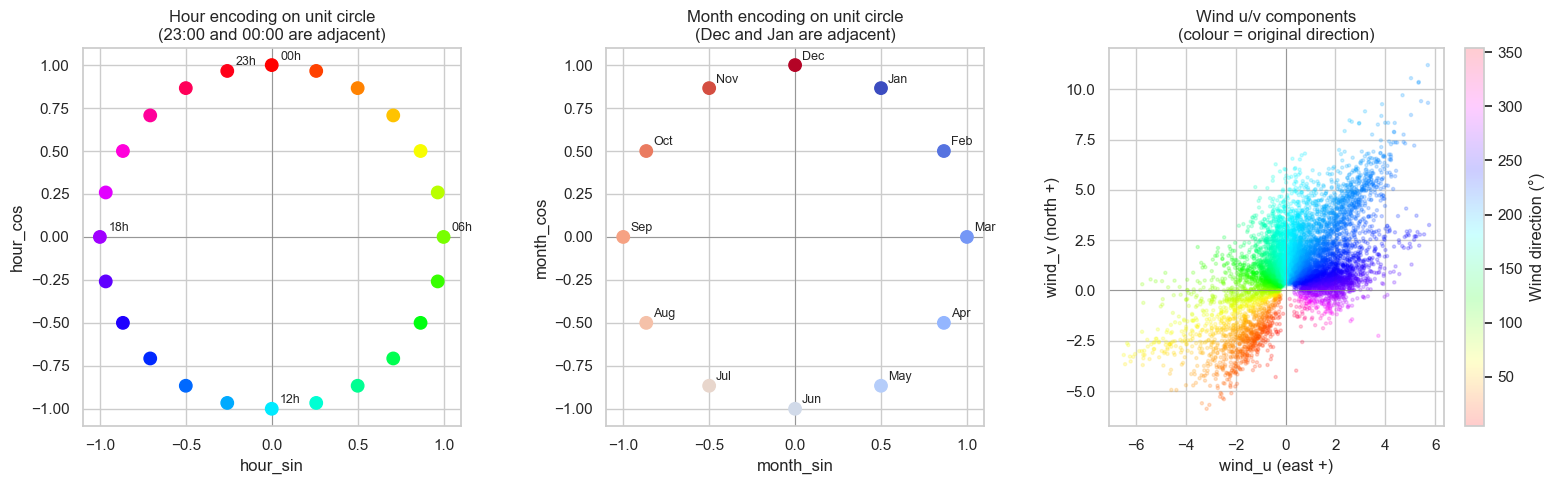

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Hour encoding
hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

axes[0].scatter(hour_sin, hour_cos, c=hours, cmap="hsv", s=80, zorder=5)
for h in [0, 6, 12, 18, 23]:
    s = np.sin(2 * np.pi * h / 24)
    c = np.cos(2 * np.pi * h / 24)
    axes[0].annotate(f"{h:02d}h", (s, c),
                     textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[0].set_title("Hour encoding on unit circle\n(23:00 and 00:00 are adjacent)")
axes[0].set_xlabel("hour_sin")
axes[0].set_ylabel("hour_cos")
axes[0].set_aspect("equal")
axes[0].axhline(0, lw=0.5, color="grey")
axes[0].axvline(0, lw=0.5, color="grey")

# Month encoding
months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)
labels = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

axes[1].scatter(month_sin, month_cos, c=months, cmap="coolwarm", s=80, zorder=5)
for i, (s, c, lab) in enumerate(zip(month_sin, month_cos, labels)):
    axes[1].annotate(lab, (s, c),
                     textcoords="offset points", xytext=(5, 4), fontsize=9)
axes[1].set_title("Month encoding on unit circle\n(Dec and Jan are adjacent)")
axes[1].set_xlabel("month_sin")
axes[1].set_ylabel("month_cos")
axes[1].set_aspect("equal")
axes[1].axhline(0, lw=0.5, color="grey")
axes[1].axvline(0, lw=0.5, color="grey")

# Wind u/v scatter — coloured by original wind direction
scatter = axes[2].scatter(
    df_features["wind_u"], df_features["wind_v"],
    c=df_clean["wind_direction"].reindex(df_features.index),
    cmap="hsv", alpha=0.2, s=5
)
plt.colorbar(scatter, ax=axes[2], label="Wind direction (°)")
axes[2].set_title("Wind u/v components\n(colour = original direction)")
axes[2].set_xlabel("wind_u (east +)")
axes[2].set_ylabel("wind_v (north +)")
axes[2].axhline(0, lw=0.5, color="grey")
axes[2].axvline(0, lw=0.5, color="grey")

plt.tight_layout()
plt.show()

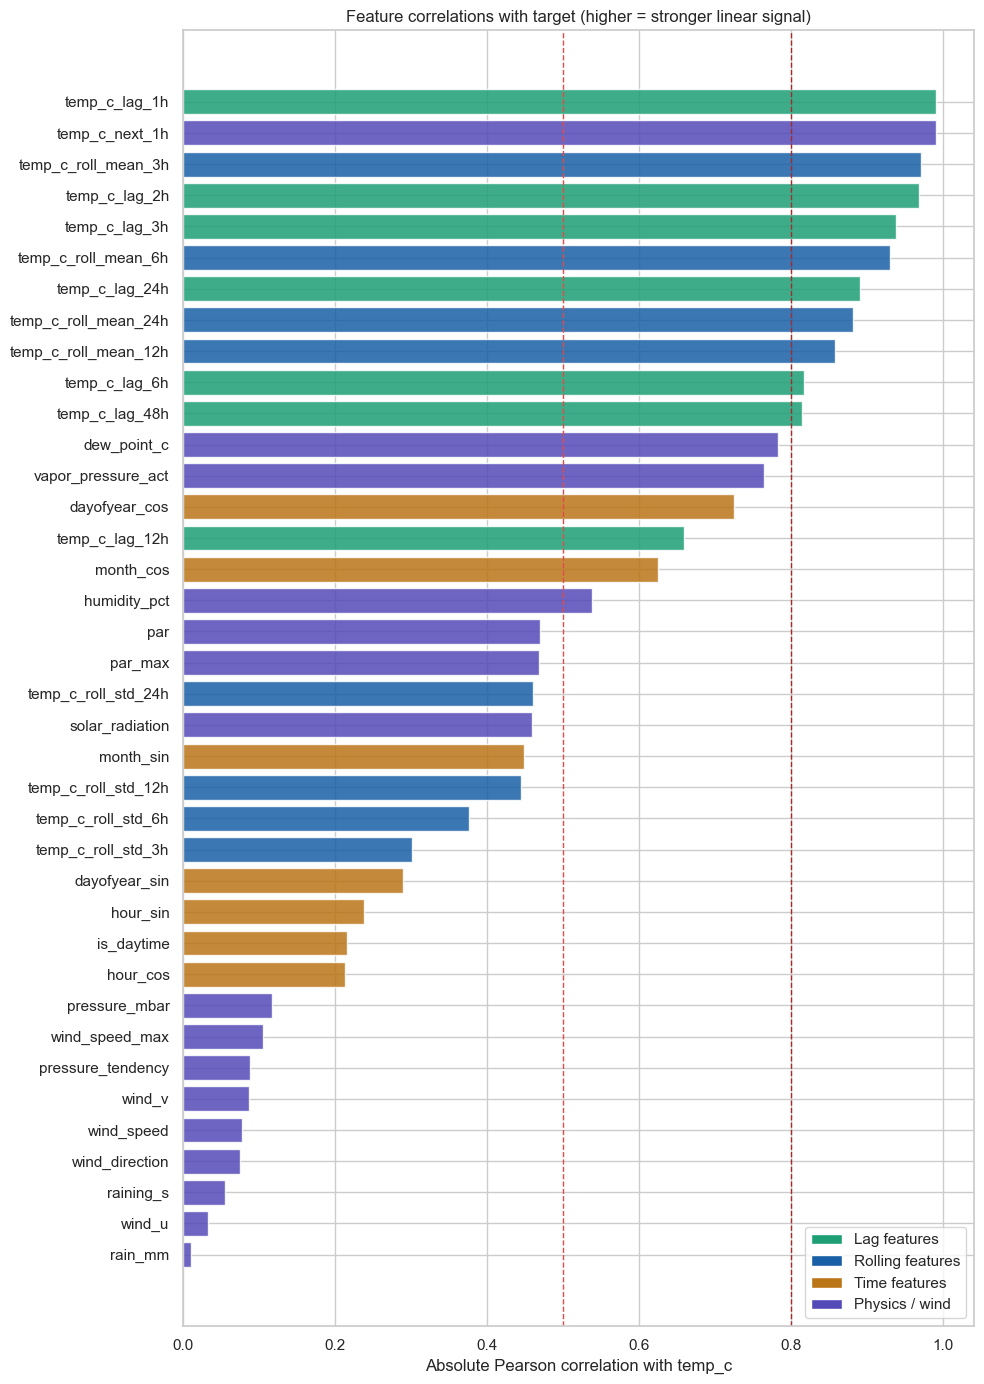

In [10]:
target = "temp_c"
feature_cols = [c for c in df_features.columns if c != target]

corr = (
    df_features[feature_cols]
    .corrwith(df_features[target])
    .abs()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 14))
colors = ["#1D9E75" if "lag" in c
          else "#185FA5" if "roll" in c
          else "#BA7517" if any(t in c for t in ["sin","cos","daytime"])
          else "#534AB7"
          for c in corr.index]

ax.barh(corr.index, corr.values, color=colors, alpha=0.85)
ax.axvline(0.5, color="#E24B4A", lw=1, ls="--", label="r=0.5")
ax.axvline(0.8, color="#A32D2D", lw=1, ls="--", label="r=0.8")
ax.set_xlabel("Absolute Pearson correlation with temp_c")
ax.set_title("Feature correlations with target (higher = stronger linear signal)")
ax.legend()

# Legend for colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1D9E75", label="Lag features"),
    Patch(facecolor="#185FA5", label="Rolling features"),
    Patch(facecolor="#BA7517", label="Time features"),
    Patch(facecolor="#534AB7", label="Physics / wind"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

In [11]:
output_path = cfg.features_data_path
output_path.parent.mkdir(parents=True, exist_ok=True)

df_features.to_parquet(output_path)

# Round-trip verification
df_verify = pd.read_parquet(output_path)
assert df_verify.shape == df_features.shape

print(f"✅ Feature matrix saved to: {output_path}")
print(f"   Shape  : {df_features.shape}")
print(f"   Size   : {output_path.stat().st_size / 1024:.1f} KB")
print(f"\nFeature groups:")
lag_cols  = [c for c in df_features.columns if "lag"  in c]
roll_cols = [c for c in df_features.columns if "roll" in c]
time_cols = [c for c in df_features.columns if any(t in c for t in ["sin","cos","daytime"])]
wind_cols = [c for c in df_features.columns if "wind_" in c]
phys_cols = [c for c in df_features.columns if c in ["dew_depression","pressure_tendency"]]

print(f"  Lag features    : {len(lag_cols)}")
print(f"  Rolling features: {len(roll_cols)}")
print(f"  Time features   : {len(time_cols)}")
print(f"  Wind components : {len(wind_cols)}")
print(f"  Physics features: {len(phys_cols)}")
print(f"  Target + raw    : {df_features.shape[1] - len(lag_cols) - len(roll_cols) - len(time_cols) - len(wind_cols) - len(phys_cols)}")

✅ Feature matrix saved to: C:\Users\CDAC\Documents\AI\weather\data\features\weather_features.parquet
   Shape  : (8709, 39)
   Size   : 1689.0 KB

Feature groups:
  Lag features    : 7
  Rolling features: 8
  Time features   : 7
  Wind components : 5
  Physics features: 1
  Target + raw    : 11


In [12]:
import sys, os
sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))

import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")

from src.config import cfg
from src.data.loader import load_processed
from src.features.transforms import build_feature_matrix

# 1. Load cleaned parquet (from Phase 3 — this one is fine)
df_clean = load_processed()
print(f"Loaded clean data: {df_clean.shape}")

# 2. Delete the stale features parquet
if cfg.features_data_path.exists():
    os.remove(cfg.features_data_path)
    print(f"Deleted stale file: {cfg.features_data_path}")

# 3. Rebuild from scratch
df_features = build_feature_matrix(df_clean.copy(), forecast_horizon=1)

# 4. Verify before saving
MUST_BE_GONE = [
    "air_density", "dew_depression", "vapor_pressure_max",
    "vapor_pressure_def", "specific_humidity", "h2o_concentration",
    "output_temp", "temp_potential_k", "temp_logged",
]
still_present = [c for c in MUST_BE_GONE if c in df_features.columns]

if still_present:
    print(f"\n❌ STOP — these columns are still present: {still_present}")
    print("   transforms.py was not saved correctly. Fix it and re-run.")
else:
    df_features.to_parquet(cfg.features_data_path)
    print(f"\n✅ Saved clean features: {df_features.shape}")
    print(f"\nAll columns:")
    for i, c in enumerate(df_features.columns, 1):
        print(f"  {i:2}. {c}")

INFO | src.data.loader | Loading processed data from: C:\Users\CDAC\Documents\AI\weather\data\processed\weather_clean.parquet
INFO | src.data.loader | Loaded processed data: (8785, 21)
INFO | src.features.transforms | ==================================================
INFO | src.features.transforms | Building feature matrix (horizon=1h)
INFO | src.features.transforms | Input:  8,785 rows × 21 columns
INFO | src.features.transforms | Added cyclical time features: hour, month, dayofyear, is_daytime
INFO | src.features.transforms | Added wind vector components: wind_u, wind_v
INFO | src.features.transforms | Added pressure_tendency
INFO | src.features.transforms | Added 7 lag features: [1, 2, 3, 6, 12, 24, 48]
INFO | src.features.transforms | Added rolling mean+std for windows (hours): [3, 6, 12, 24]
INFO | src.features.transforms | Created forecast target 'temp_c_next_1h' (horizon=1h, last 1 rows will be NaN)
INFO | src.features.transforms | Dropped 8 redundant/derived columns: ['temp_po

Loaded clean data: (8785, 21)
Deleted stale file: C:\Users\CDAC\Documents\AI\weather\data\features\weather_features.parquet

✅ Saved clean features: (8709, 39)

All columns:
   1. pressure_mbar
   2. temp_c
   3. dew_point_c
   4. humidity_pct
   5. vapor_pressure_act
   6. wind_speed
   7. wind_speed_max
   8. wind_direction
   9. rain_mm
  10. raining_s
  11. solar_radiation
  12. par
  13. par_max
  14. hour_sin
  15. hour_cos
  16. month_sin
  17. month_cos
  18. dayofyear_sin
  19. dayofyear_cos
  20. is_daytime
  21. wind_u
  22. wind_v
  23. pressure_tendency
  24. temp_c_lag_1h
  25. temp_c_lag_2h
  26. temp_c_lag_3h
  27. temp_c_lag_6h
  28. temp_c_lag_12h
  29. temp_c_lag_24h
  30. temp_c_lag_48h
  31. temp_c_roll_mean_3h
  32. temp_c_roll_std_3h
  33. temp_c_roll_mean_6h
  34. temp_c_roll_std_6h
  35. temp_c_roll_mean_12h
  36. temp_c_roll_std_12h
  37. temp_c_roll_mean_24h
  38. temp_c_roll_std_24h
  39. temp_c_next_1h
